Import the libraries needed

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Get the data file

In [3]:
df = pd.read_csv("titanic.csv")

Copy the original data file

In [4]:
data = df.copy()

Print the first 5 rows of data file

In [5]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Print the last 5 rows of data file

In [6]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Know the dimensions of data

In [7]:
data.shape

(891, 12)

Find the missing or null values

In [8]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Replace the Null Or missing values by mean or median or mode

In [9]:
data["Age"].fillna(data["Age"].mean(),inplace=True)

C:\Users\nj932\AppData\Local\Temp\ipykernel_19464\948062835.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data["Age"].fillna(data["Age"].mean(),inplace=True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

See the result

In [10]:
data["Age"].isnull().sum()

np.int64(177)

Delete the unwanted Columns

In [11]:
data.drop(["Cabin","Embarked"],axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000


Find the corelation between the diff columns
Before that need to covert the string values to numerical values

In [12]:
data["Sex"] = data["Sex"].map({"female":0,"male":1})

In [13]:
data[["Sex","Survived"]].corr()

,Sex,Survived
Sex,1.000000,-0.543351
Survived,-0.543351,1.000000


In [14]:
corr_matrix = data.corr(numeric_only=True) 

In [15]:
corr_matrix

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.042939,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.543351,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,0.131900,-0.369226,0.083081,0.018443,-0.549500
Sex,0.042939,-0.543351,0.131900,1.000000,0.093254,-0.114631,-0.245489,-0.182333
Age,0.036847,-0.077221,-0.369226,0.093254,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.114631,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.245489,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,-0.182333,0.096067,0.159651,0.216225,1.000000


Applying standization 

z= x−μ/σ


In [16]:
numeric_df = data.select_dtypes(include=['float64', 'int64']).copy()
numeric_df.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,1,22.0,1,0,7.2500
1,2,1,1,0,38.0,1,0,71.2833
2,3,1,3,0,26.0,0,0,7.9250
3,4,1,1,0,35.0,1,0,53.1000
4,5,0,3,1,35.0,0,0,8.0500


In [18]:
standardized_df = (numeric_df - numeric_df.mean()) / numeric_df.std()
standardized_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,-1.729137,-0.788829,0.826913,0.737281,-0.530005,0.432550,-0.473408,-0.502163
1,-1.725251,1.266279,-1.565228,-1.354813,0.571430,0.432550,-0.473408,0.786404
2,-1.721365,1.266279,0.826913,-1.354813,-0.254646,-0.474279,-0.473408,-0.488580
3,-1.717480,1.266279,-1.565228,-1.354813,0.364911,0.432550,-0.473408,0.420494
4,-1.713594,-0.788829,0.826913,0.737281,0.364911,-0.474279,-0.473408,-0.486064


Normalization

x_normalized = x−x_min / x_max −x_min

In [19]:
normalized_df = (numeric_df - numeric_df.min()) / (numeric_df.max() - numeric_df.min())
normalized_df.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0.000000,0.0,1.0,1.0,0.271174,0.125,0.0,0.014151
1,0.001124,1.0,0.0,0.0,0.472229,0.125,0.0,0.139136
2,0.002247,1.0,1.0,0.0,0.321438,0.000,0.0,0.015469
3,0.003371,1.0,0.0,0.0,0.434531,0.125,0.0,0.103644
4,0.004494,0.0,1.0,1.0,0.434531,0.000,0.0,0.015713


In [20]:
data = data[['Age', 'Fare']].dropna()

Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = data[(data['Fare'] >= lower_bound) & (data['Fare'] <= upper_bound)]

In [21]:
df_no_outliers

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
885,39.0,29.1250
886,27.0,13.0000
887,19.0,30.0000
889,26.0,30.0000


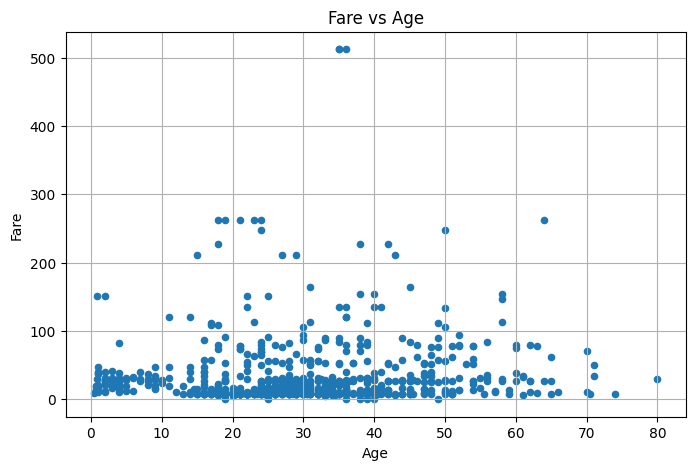

In [28]:
data.plot(kind='scatter', x='Age', y='Fare', title='Fare vs Age', figsize=(8, 5))
plt.grid(True)
plt.show()

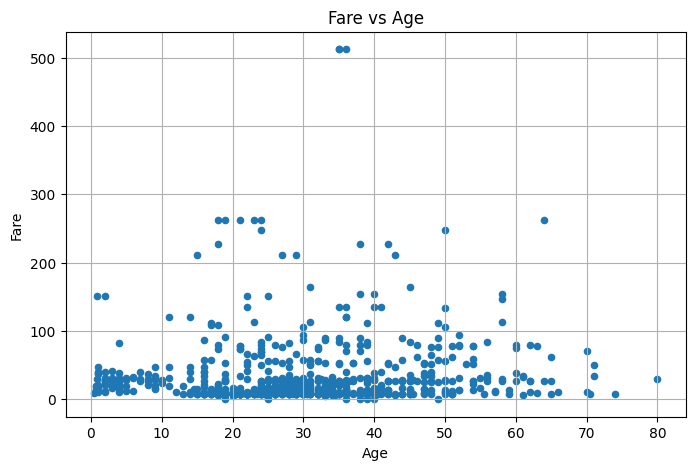

In [22]:
df.plot(kind='scatter', x='Age', y='Fare', title='Fare vs Age', figsize=(8, 5))

plt.grid(True)
plt.show()

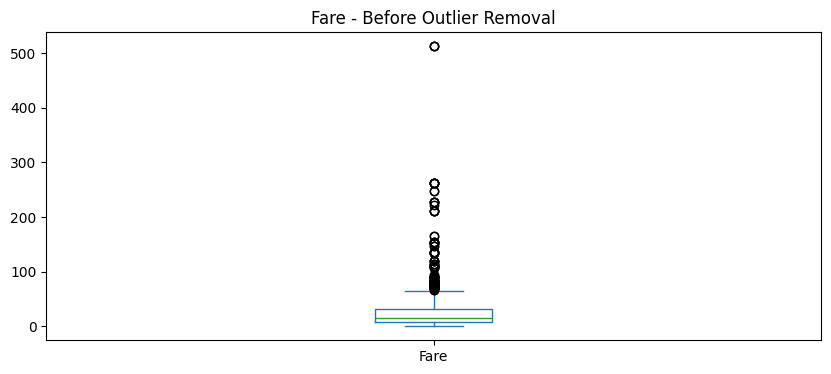

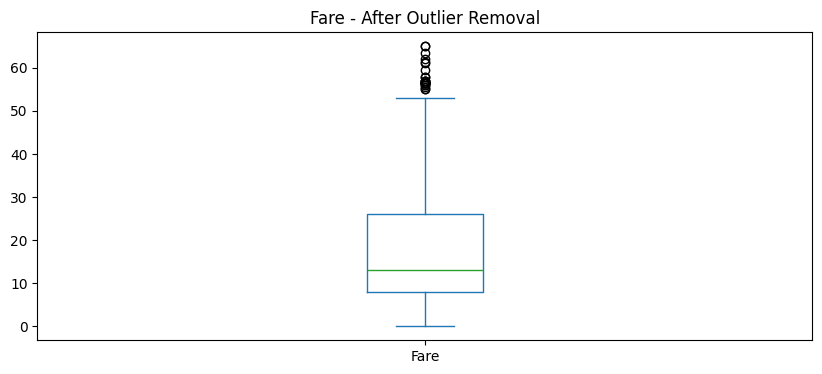

In [23]:
plt.figure(figsize=(10, 4))
df['Fare'].plot(kind='box', title='Fare - Before Outlier Removal')
plt.show()
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
df_no_outliers = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]
plt.figure(figsize=(10, 4))
df_no_outliers['Fare'].plot(kind='box', title='Fare - After Outlier Removal')
plt.show()